## Electricity Cost Prediction — Final Project


**Goal**: Predict the electricity cost of a building/site based on structural, resource-usage, and environmental features.

**Dataset**: Electricity Cost Prediction Dataset (10,000 rows, 9 columns)

This notebook covers: data understanding, cleaning, exploratory data analysis, statistical analysis, machine learning modeling, evaluation, and prediction intervals.

## 1. Data Loading & Understanding

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
RANDOM_STATE = 42

df = pd.read_csv('electricity_cost_dataset.csv')
df.head()

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0


In [2]:
print("Shape of dataset (rows, columns):", df.shape)

Shape of dataset (rows, columns): (10000, 9)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site area             10000 non-null  int64  
 1   structure type        10000 non-null  str    
 2   water consumption     10000 non-null  float64
 3   recycling rate        10000 non-null  int64  
 4   utilisation rate      10000 non-null  int64  
 5   air qality index      10000 non-null  int64  
 6   issue reolution time  10000 non-null  int64  
 7   resident count        10000 non-null  int64  
 8   electricity cost      10000 non-null  float64
dtypes: float64(2), int64(6), str(1)
memory usage: 802.8 KB


In [4]:
df.describe()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2757.775100,3494.057100,49.598000,64.842200,99.468600,36.402600,85.573100,2837.845000
std,1293.059959,2076.181117,23.430141,20.432965,58.014526,20.623905,107.876179,1106.997441
min,501.000000,1000.000000,10.000000,30.000000,0.000000,1.000000,0.000000,500.000000
25%,1624.000000,1779.000000,29.750000,47.000000,49.000000,19.000000,0.000000,1954.000000
50%,2773.500000,3047.500000,49.000000,65.000000,100.000000,36.000000,39.000000,2760.000000
75%,3874.000000,4811.000000,70.000000,83.000000,150.000000,54.000000,142.000000,3632.000000
max,5000.000000,10894.000000,90.000000,100.000000,200.000000,72.000000,489.000000,6446.000000


In [37]:
target = 'electricity cost'
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = [c for c in df.select_dtypes(include=np.number).columns if c != target]

"Target variable:", target
"Categorical variables:", categorical_cols
"Numerical variables:", numerical_cols

/var/folders/gn/n36_sdl92lz5kl1ksrnynjkw0000gn/T/ipykernel_1435/3647762803.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


('Numerical variables:',
 ['site area',
  'water consumption',
  'recycling rate',
  'utilisation rate',
  'air qality index',
  'issue reolution time',
  'resident count'])

In [6]:
df[categorical_cols[0]].value_counts()

structure type
Residential    3939
Commercial     3005
Mixed-use      2052
Industrial     1004
Name: count, dtype: int64

## 2. Data Cleaning



In [7]:
df.isnull().sum()

site area               0
structure type          0
water consumption       0
recycling rate          0
utilisation rate        0
air qality index        0
issue reolution time    0
resident count          0
electricity cost        0
dtype: int64

In [40]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [42]:
# outlier 
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum(), lower, upper

outlier_summary = []
for col in numerical_cols + [target]:
    n_out, lower, upper = count_outliers_iqr(df[col])
    outlier_summary.append({'column': col, 'n_outliers': n_out, 'lower_bound': round(lower,2), 'upper_bound': round(upper,2)})

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,column,n_outliers,lower_bound,upper_bound
0,site area,0,-1751.00,7249.00
1,water consumption,43,-2769.00,9359.00
2,recycling rate,0,-30.62,130.38
3,utilisation rate,0,-7.00,137.00
4,air qality index,0,-102.50,301.50
5,issue reolution time,0,-33.50,106.50
6,resident count,289,-213.00,355.00
7,electricity cost,3,-563.00,6149.00


In [43]:
df_clean = df.copy()

for col in ['water consumption', 'resident count', target]:
    n_out, lower, upper = count_outliers_iqr(df_clean[col])
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print("Outliers capped. New shape:", df_clean.shape)

Outliers capped. New shape: (10000, 9)


In [45]:
# Verify outliers after capping
for col in ['water consumption', 'resident count', target]:
    n_out, _, _ = count_outliers_iqr(df_clean[col])
    print(col, ": remaining outliers:", n_out)

water consumption : remaining outliers: 0
resident count : remaining outliers: 0
electricity cost : remaining outliers: 0


## 3. Exploratory Data Analysis (EDA)

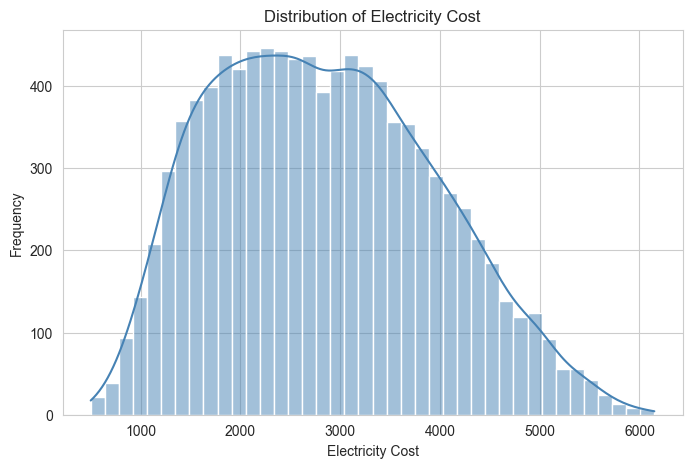

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean[target], kde=True, bins=40, color='steelblue')
plt.title('Distribution of Electricity Cost')
plt.xlabel('Electricity Cost')
plt.ylabel('Frequency')
plt.show()

/var/folders/gn/n36_sdl92lz5kl1ksrnynjkw0000gn/T/ipykernel_1435/3264753534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='structure type', y=target, palette='Set2')


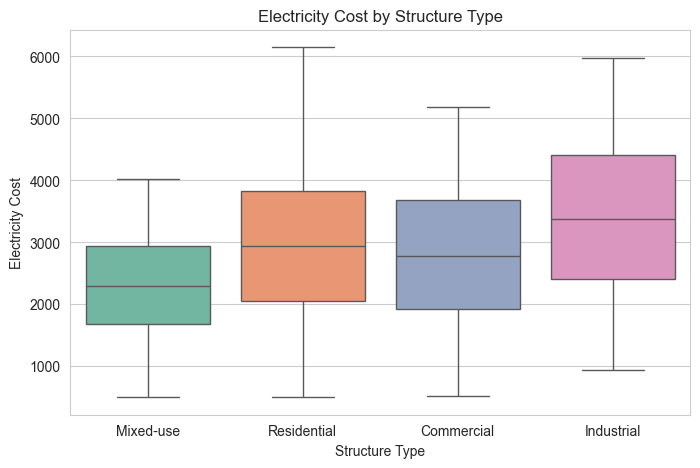

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='structure type', y=target, palette='Set2')
plt.title('Electricity Cost by Structure Type')
plt.xlabel('Structure Type')
plt.ylabel('Electricity Cost')
plt.show()

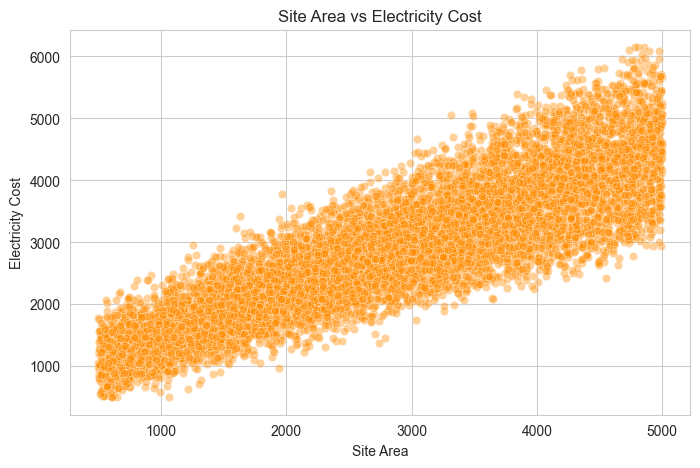

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='site area', y=target, alpha=0.4, color='darkorange')
plt.title('Site Area vs Electricity Cost')
plt.xlabel('Site Area')
plt.ylabel('Electricity Cost')
plt.show()

### 3.4 Correlation Heatmap

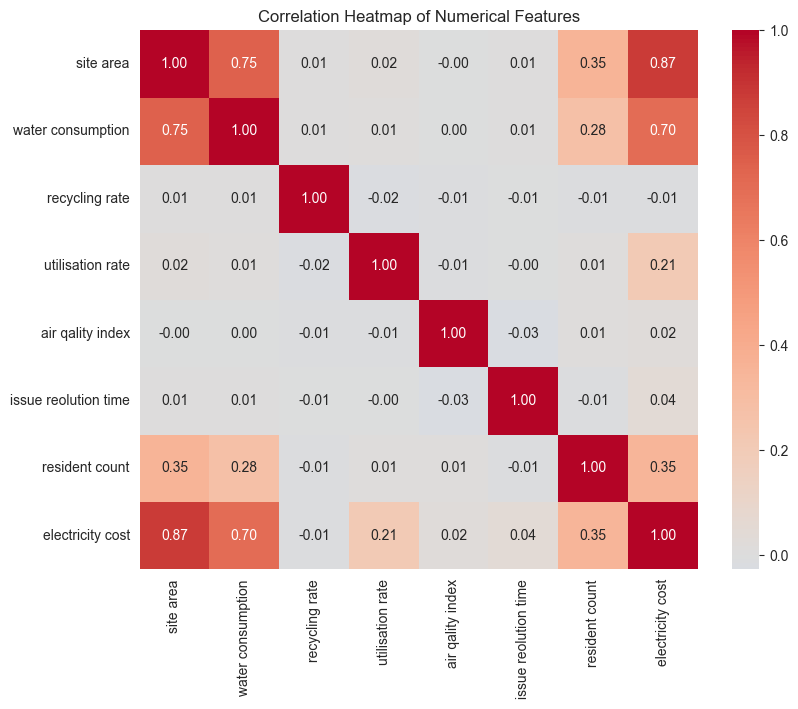

In [15]:
plt.figure(figsize=(9,7))
corr = df_clean[numerical_cols + [target]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 3.5 Resident Count vs Electricity Cost

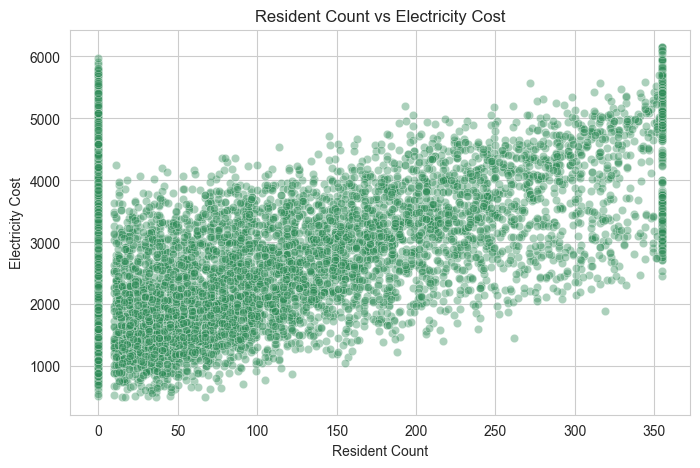

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='resident count', y=target, alpha=0.4, color='seagreen')
plt.title('Resident Count vs Electricity Cost')
plt.xlabel('Resident Count')
plt.ylabel('Electricity Cost')
plt.show()

## 4. Statistical Analysis



In [48]:
groups = [df_clean.loc[df_clean['structure type'] == cat, target] for cat in df_clean['structure type'].unique()]
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nSince p-value ({p_value:.6f}) < alpha ({alpha}), we REJECT the null hypothesis.")
    print("There IS a statistically significant difference in electricity cost across structure types.")
else:
    print(f"\nSince p-value ({p_value:.6f}) >= alpha ({alpha}), we FAIL TO REJECT the null hypothesis.")
    print("There is NO statistically significant difference in electricity cost across structure types.")

F-statistic: 293.8533
P-value: 0.000000

Since p-value (0.000000) < alpha (0.05), we REJECT the null hypothesis.
There IS a statistically significant difference in electricity cost across structure types.


In [49]:
import statsmodels.api as sm

X_ols = df_clean[numerical_cols]
X_ols = sm.add_constant(X_ols)
y_ols = df_clean[target]

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:       electricity cost   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     6076.
Date:                Sun, 16 Aug 2026   Prob (F-statistic):               0.00
Time:                        02:54:32   Log-Likelihood:                -75984.
No. Observations:               10000   AIC:                         1.520e+05
Df Residuals:                    9992   BIC:                         1.520e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   17.2550 

**Interpretation of coefficients:**
- Each coefficient represents the expected change in `electricity cost` for a one-unit increase in that feature, holding all other features constant.
- The **standard error** measures how precisely each coefficient is estimated — smaller standard errors mean more reliable estimates.
- The **p-value** for each coefficient tests whether that feature has a statistically significant relationship with electricity cost (p < 0.05 is typically considered significant).
- Features with p-values above 0.05 do not show strong evidence of a real linear relationship with the target once the other variables are accounted for.

In [19]:
mean_cost = df_clean[target].mean()
sem = stats.sem(df_clean[target])  # standard error of the mean
ci_low, ci_high = stats.t.interval(confidence=0.95, df=len(df_clean)-1, loc=mean_cost, scale=sem)

print(f"Sample Mean Electricity Cost: {mean_cost:.2f}")
print(f"95% Confidence Interval: ({ci_low:.2f}, {ci_high:.2f})")

Sample Mean Electricity Cost: 2837.79
95% Confidence Interval: (2816.09, 2859.48)


### 4.4 Bootstrap Resampling

In [50]:
np.random.seed(RANDOM_STATE)
n_iterations = 2000
bootstrap_means = []

data_values = df_clean[target].values
n = len(data_values)

for _ in range(n_iterations):
    sample = np.random.choice(data_values, size=n, replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)
boot_ci_low, boot_ci_high = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"Bootstrap mean of electricity cost: {bootstrap_means.mean():.2f}")
print(f"Bootstrap 95% Confidence Interval: ({boot_ci_low:.2f}, {boot_ci_high:.2f})")

Bootstrap mean of electricity cost: 2837.34
Bootstrap 95% Confidence Interval: (2815.58, 2859.23)


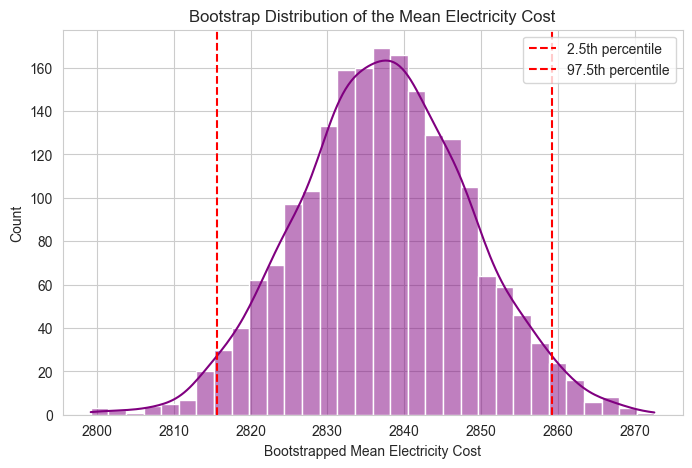

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(bootstrap_means, kde=True, color='purple')
plt.axvline(boot_ci_low, color='red', linestyle='--', label='2.5th percentile')
plt.axvline(boot_ci_high, color='red', linestyle='--', label='97.5th percentile')
plt.title('Bootstrap Distribution of the Mean Electricity Cost')
plt.xlabel('Bootstrapped Mean Electricity Cost')
plt.legend()
plt.show()

## 5. Data Preparation for Machine Learning



In [22]:
df_model = df_clean.copy()
df_model = pd.get_dummies(df_model, columns=['structure type'], drop_first=True)
df_model.head()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost,structure type_Industrial,structure type_Mixed-use,structure type_Residential
0,1360,2519.0,69,52,188,1,72,1420.0,False,True,False
1,4272,2324.0,50,76,165,65,261,3298.0,False,True,False
2,3592,2701.0,20,94,198,39,117,3115.0,False,True,False
3,966,1000.0,13,60,74,3,35,1575.0,False,False,True
4,4926,5990.0,23,65,32,57,185,4301.0,False,False,True


In [23]:
X = df_model.drop(columns=[target])
y = df_model[target]

print("Features used:", list(X.columns))
print("X shape:", X.shape, " y shape:", y.shape)

Features used: ['site area', 'water consumption', 'recycling rate', 'utilisation rate', 'air qality index', 'issue reolution time', 'resident count', 'structure type_Industrial', 'structure type_Mixed-use', 'structure type_Residential']
X shape: (10000, 10)  y shape: (10000,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 10)
Testing set size: (2000, 10)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,structure type_Industrial,structure type_Mixed-use,structure type_Residential
9254,1.655867,2.266502,0.276341,0.014784,-0.545307,-0.010911,1.014706,-0.336104,1.990673,-0.803166
1561,-0.473718,-0.902100,1.684179,-1.015386,-0.872624,-0.592515,0.263879,-0.336104,1.990673,-0.803166
1670,0.181897,-0.539493,0.617636,0.407230,-1.578941,0.328358,1.727030,-0.336104,1.990673,-0.803166
6087,1.417180,-0.470631,-1.558114,-1.064442,-1.217169,-1.561856,-0.804607,-0.336104,-0.502343,-0.803166
6669,1.405556,1.114152,0.916268,-1.260665,0.005965,0.134490,0.379391,-0.336104,1.990673,-0.803166


## 6. Machine Learning Models

We train two regression models: **Linear Regression** and **KNN Regressor**, and use `GridSearchCV` to tune the KNN hyperparameter (`n_neighbors`).

### 6.1 Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
print("Linear Regression trained successfully.")

Linear Regression trained successfully.


### 6.2 KNN Regressor with Hyperparameter Tuning (GridSearchCV)

In [27]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': list(range(2, 21))}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print("Best k (n_neighbors):", knn_grid.best_params_)
knn_model = knn_grid.best_estimator_

y_pred_knn = knn_model.predict(X_test_scaled)
print("KNN Regressor trained successfully with the best hyperparameter.")

Best k (n_neighbors): {'n_neighbors': 11}
KNN Regressor trained successfully with the best hyperparameter.


## 7. Model Evaluation

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae,2), 'MSE': round(mse,2), 'RMSE': round(rmse,2), 'R2': round(r2,4)}

results = []
results.append(evaluate_model(y_test, y_pred_lr, 'Linear Regression'))
results.append(evaluate_model(y_test, y_pred_knn, f'KNN Regressor (k={knn_grid.best_params_["n_neighbors"]})'))

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,245.88,97375.95,312.05,0.9219
1,KNN Regressor (k=11),219.69,76986.39,277.46,0.9383


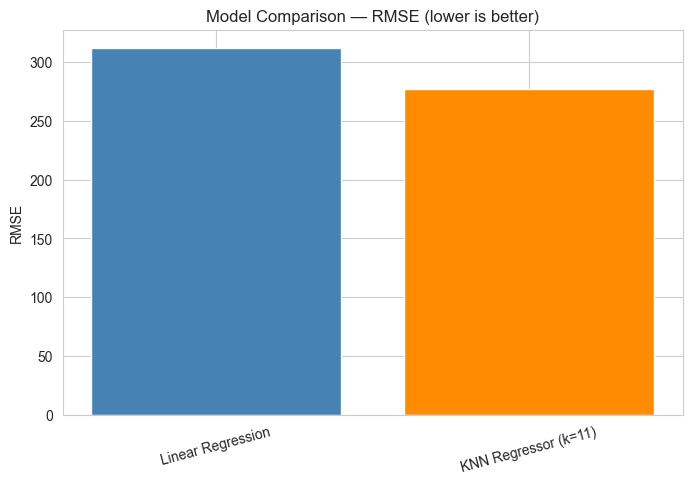

In [29]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['RMSE'], color=['steelblue','darkorange'])
plt.title('Model Comparison — RMSE (lower is better)')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.show()

In [30]:
best_model_name = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
print("Best performing model based on RMSE:", best_model_name)

if 'Linear' in best_model_name:
    final_model = lr_model
    y_pred_final = y_pred_lr
else:
    final_model = knn_model
    y_pred_final = y_pred_knn

Best performing model based on RMSE: KNN Regressor (k=11)


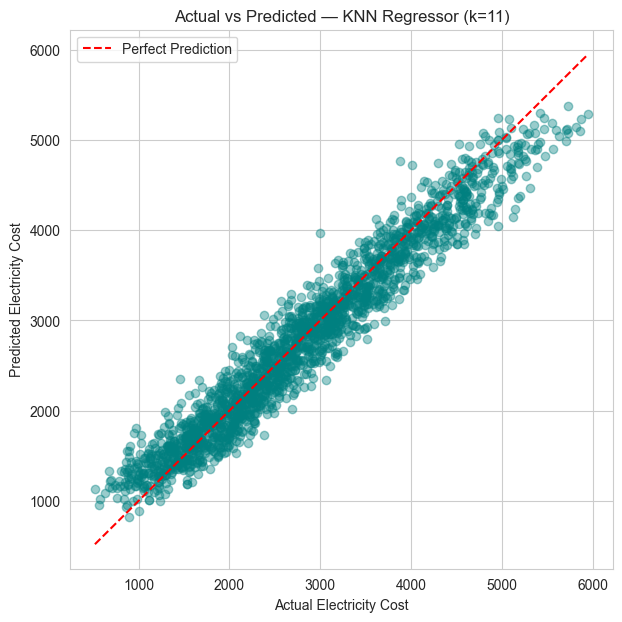

In [31]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_final, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Electricity Cost')
plt.ylabel('Predicted Electricity Cost')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.show()

## 8. Prediction Interval (Bootstrap)



In [32]:
np.random.seed(RANDOM_STATE)
n_boot = 200
boot_preds = np.zeros((n_boot, len(X_test_scaled)))

train_indices = np.arange(len(X_train_scaled))

for i in range(n_boot):
    boot_idx = np.random.choice(train_indices, size=len(train_indices), replace=True)
    X_boot = X_train_scaled.iloc[boot_idx]
    y_boot = y_train.iloc[boot_idx]

    if 'Linear' in best_model_name:
        m = LinearRegression()
    else:
        m = KNeighborsRegressor(n_neighbors=knn_grid.best_params_['n_neighbors'])

    m.fit(X_boot, y_boot)
    boot_preds[i, :] = m.predict(X_test_scaled)

pred_lower = np.percentile(boot_preds, 2.5, axis=0)
pred_upper = np.percentile(boot_preds, 97.5, axis=0)
pred_mean = boot_preds.mean(axis=0)

interval_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted (mean)': np.round(pred_mean, 2),
    'Lower 95% bound': np.round(pred_lower, 2),
    'Upper 95% bound': np.round(pred_upper, 2)
}).reset_index(drop=True)

interval_df.head(10)

,Actual,Predicted (mean),Lower 95% bound,Upper 95% bound
0,2027.0,2697.80,2358.57,3011.48
1,1744.0,1860.47,1636.54,2105.28
2,4233.0,3899.98,3717.90,4140.98
3,1912.0,1859.31,1669.53,2086.74
4,1757.0,1805.77,1602.61,2028.23
5,2301.0,2257.29,2070.60,2424.59
6,3230.0,2961.64,2735.69,3229.87
7,1161.0,1289.85,1065.80,1496.25
8,4555.0,4264.11,4046.31,4503.48
9,4761.0,4345.36,4091.88,4631.14


In [33]:
coverage = np.mean((y_test.values >= pred_lower) & (y_test.values <= pred_upper))
print(f"Percentage of actual test values falling inside the 95% prediction interval: {coverage*100:.1f}%")

Percentage of actual test values falling inside the 95% prediction interval: 60.8%


## 9. Save the Final Model



In [34]:
import joblib

joblib.dump(final_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

print("Saved: model.pkl, scaler.pkl, feature_columns.pkl")
print("Final model used:", best_model_name)

Saved: model.pkl, scaler.pkl, feature_columns.pkl
Final model used: KNN Regressor (k=11)
